In [1]:
import sys
import Util

!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install -U torch --index-url https://download.pytorch.org/whl/cu128
!{sys.executable} -m pip install -U optuna

Looking in indexes: https://download.pytorch.org/whl/cu128


In [2]:
import pandas as pd
import optuna
import torch
import Util

from Util import DatasetGenerator, Visualization, Table
from dataclasses import dataclass
from torch.nn.functional import mse_loss
from torch.nn import Sigmoid

C:\Users\Luco1421\Desktop\U\ia\TPs\TP3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE = Util.DEVICE
TYPE = Util.TYPE

# Global visualization utility instance
visualization = Visualization()

In [4]:
def xavier_glorot_init(fan_in, fan_out):
    return (6 / (fan_in + fan_out)) ** 0.5

class MultilayerPerceptron:
    def __init__(self, neurons_per_layer : list [int], alpha : float, gamma : float, max_weights : float):
        self.d, self.m, self.k = neurons_per_layer

        self.alpha = alpha
        self.gamma = gamma
        self.max_weights = max_weights

        self.xavier_glorot_o = xavier_glorot_init(self.d + 1, self.m)
        self.xavier_glorot_s = xavier_glorot_init(self.m + 1, self.k)

        self.W_o = torch.empty(self.d + 1, self.m, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_o, self.xavier_glorot_o)
        self.W_s = torch.empty(self.m + 1, self.k, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_s, self.xavier_glorot_s)

        self.delta_W_o = None
        self.delta_W_s = None

        self.P_o = None
        self.Y_o = None
        self.Y_o_bias = None
        self.P_s = None
        self.Y_s = None

        self.activation = Sigmoid()

        self.V_o = torch.zeros(self.d + 1, self.m, dtype=TYPE, device=DEVICE)
        self.V_s = torch.zeros(self.m + 1, self.k, dtype=TYPE, device=DEVICE)

    @staticmethod
    def transform_data(data):
        """! Adds a bias column to the dataset.

        @param data Input feature matrix.
        @return Transformed feature matrix with bias column.
        """

        # Create tensor of ones for bias term
        ones_tensor = torch.ones(data.shape[0], 1, device = DEVICE)

        # Concatenate bias column with input data
        return torch.cat((ones_tensor, data), dim=1)

    def forward(self, X : torch.Tensor):
        self.P_o = X @ self.W_o
        self.Y_o = self.activation(self.P_o)
        self.Y_o_bias = self.transform_data(self.Y_o)
        self.P_s = self.Y_o_bias @ self.W_s
        self.Y_s = self.activation(self.P_s)

    def backpropagate_deltas(self, T: torch.Tensor):
        # Output layer       NxK                 NxK   =   NxK
        self.delta_W_s = (self.Y_s - T) * (self.Y_s * (1 - self.Y_s))

        # Hidden layer        NxK               KxM                 NxM       =     NxM
        self.delta_W_o = (self.delta_W_s  @ self.W_s[1:, :].T) * self.Y_o * (1 - self.Y_o) # [1:, :]

    def update_weights(self, X: torch.Tensor):
        # Hidden Layer D+1xM                                                D+1xN       NxM = D+1xM
        self.V_o = self.V_o * self.gamma + self.alpha * (1 - self.gamma) * (X.T @ self.delta_W_o) / X.shape[0]
        self.W_o = (self.W_o - self.V_o).clamp(-self.max_weights, self.max_weights)

        # Output Layer  M+1xK                                                 M+1xN                 NxK   =  M+1xK
        self.V_s = self.V_s * self.gamma + self.alpha * (1 - self.gamma) * (self.Y_o_bias.T @ self.delta_W_s) / X.shape[0]
        self.W_s = (self.W_s - self.V_s).clamp(-self.max_weights, self.max_weights)

    def get_error(self, T: torch.Tensor):
        return mse_loss(self.Y_s, T).item()

    def get_accuracy(self, T: torch.Tensor):
        return (torch.argmax(self.Y_s, dim=1) == torch.argmax(T, dim=1)).float().mean().item()

    def train_mlp(self, nun_epochs: int, X : torch.Tensor, T : torch.Tensor, alpha : float | None = None, gamma : float | None = None):
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma

        history_error = []
        history_accuracy = []

        X = self.transform_data(X)
        print(X.shape)

        for _ in range(nun_epochs):
            self.forward(X)

            history_error.append(self.get_error(T))
            history_accuracy.append(self.get_accuracy(T))

            self.backpropagate_deltas(T)
            self.update_weights(X)

        self.forward(X)
        history_error.append(self.get_error(T))
        history_accuracy.append(self.get_accuracy(T))

        return history_error, history_accuracy

## Test Forward

In [5]:
def test_forward():
    X = torch.tensor([[1, 0], [0, 1]], dtype=TYPE)
    mp = MultilayerPerceptron([2, 2, 2], 0.01, 0.9, 1)
    mp.forward(X)
    assert mp.Y_s.shape[0] == X.shape[0]

# test_forward()

In [6]:
@dataclass
class DataXOR:
    X = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ], dtype=TYPE, device=DEVICE)
    M = 2
    T = torch.tensor([
        [1,0],
        [0,1],
        [0,1],
        [1,0]
    ], dtype=TYPE, device=DEVICE)
    class0 = torch.tensor([
        [0,0],
        [1,1]
    ])
    class1 = torch.tensor([
        [1,0],
        [0,1]
    ])


In [7]:
EPSILON = 0.000001

def objective_xor(trial, epsilon : float = EPSILON):
    alpha = trial.suggest_float("alpha", 45, 65, log=True)
    gamma = trial.suggest_float("gamma", 0, 1, log=False)
    mp = MultilayerPerceptron([DataXOR.X.shape[1], DataXOR.M, DataXOR.T.shape[1]], alpha, gamma, 1000)
    history_error, history_accuracy = mp.train_mlp(1000, DataXOR.X, DataXOR.T)

    if history_error[-1] < epsilon:
        accuracy = torch.tensor(history_accuracy)
        error = torch.tensor(history_error)

        visualization.make_decision_boundary_plot(mp.W_o, mp.W_s, -0.5, 1.5, DataXOR.class0, DataXOR.class1)
        visualization.make_error_plot(history_error, f"Alpha : {alpha} Gamma : {gamma} ")

        trial.set_user_attr("accuracy", torch.where(accuracy > 0.99)[0][0].item())
        trial.set_user_attr("error", torch.where(error < epsilon)[0][0].item())

    return history_error[-1]


def study(objective):
    optuna.logging.set_verbosity(optuna.logging.ERROR)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=50)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    return stud.trials

def show_best_trial(trials, epsilon : float = EPSILON):
    table = Table(pd.DataFrame(), ["Intento","Alpha", "Gamma", "Value", "Precisión","Error"], "Optimizacion")

    for t in trials:
        if t.value < epsilon:

            ind = table.obtain_row_count()

            table.add(ind, "Intento", t.number)
            table.add(ind, "Alpha", t.params["alpha"])
            table.add(ind, "Gamma", t.params["gamma"])
            table.add(ind, "Value", t.value)

            table.add(ind, "Precisión", t.user_attrs["accuracy"])
            table.add(ind, "Error", t.user_attrs["error"])

    table.show()
    table.latex()

# show_best_trial(study(objective_xor))

32000


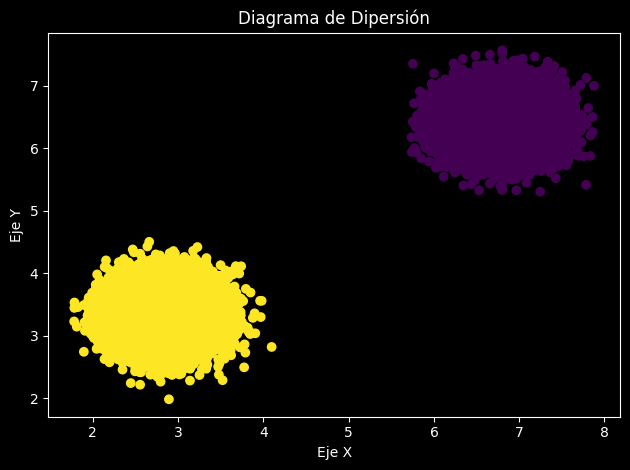

32000


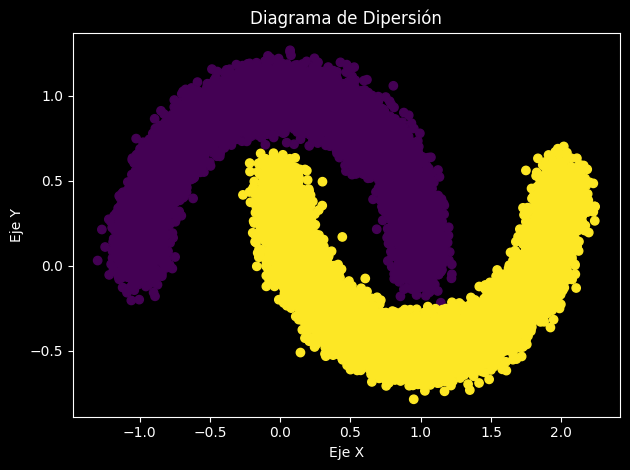

torch.Size([32000, 3])


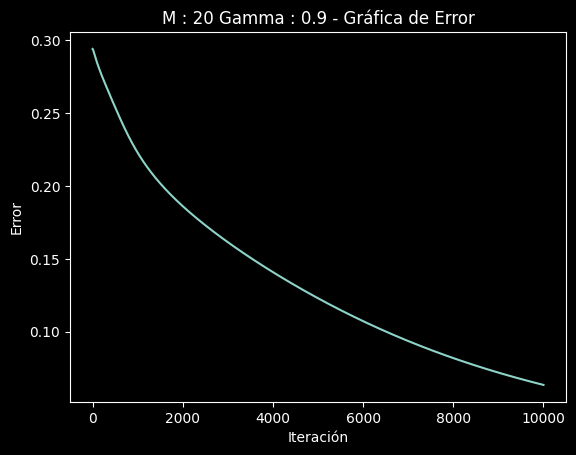

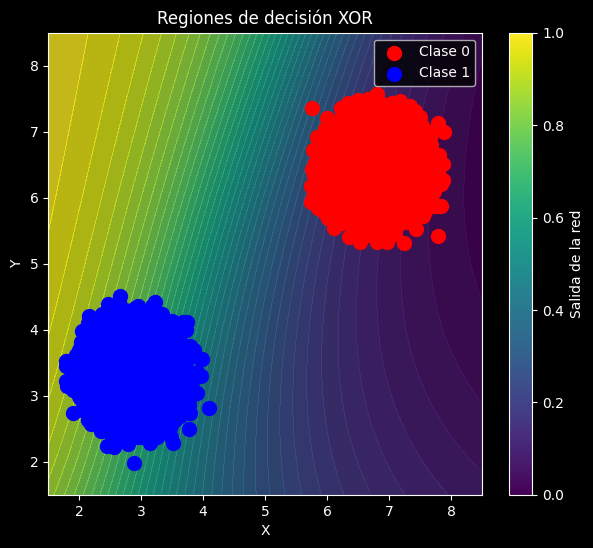

torch.Size([32000, 3])


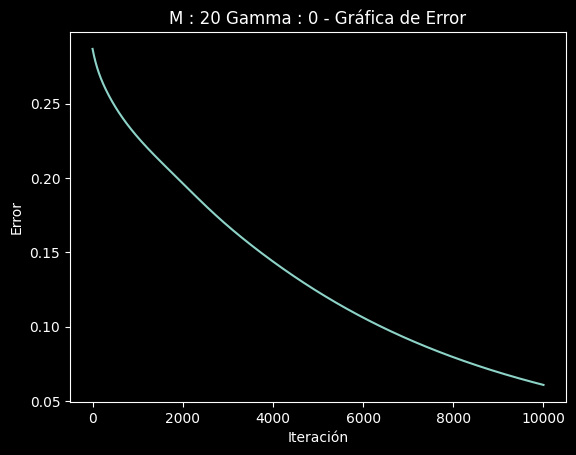

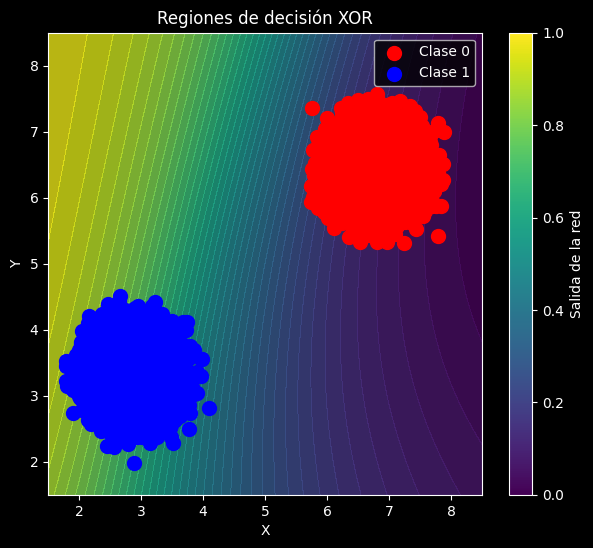

torch.Size([32000, 3])


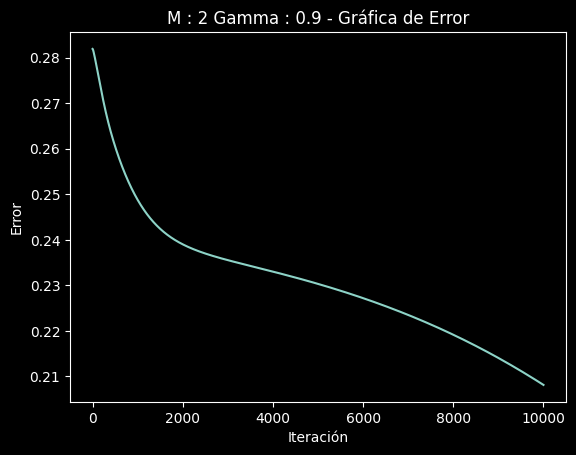

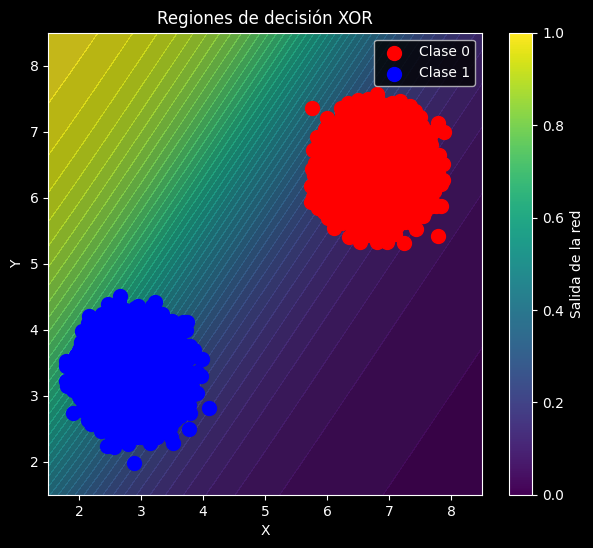

torch.Size([32000, 3])


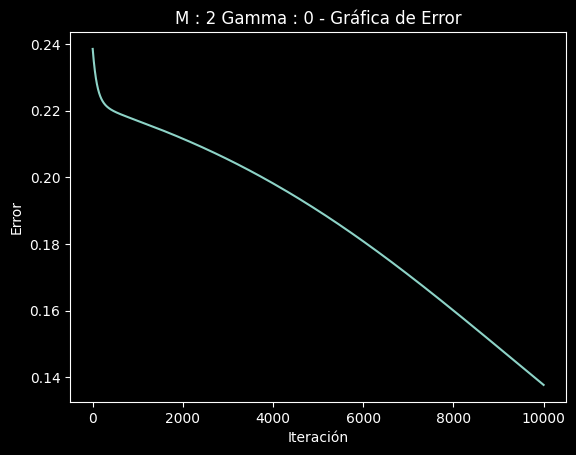

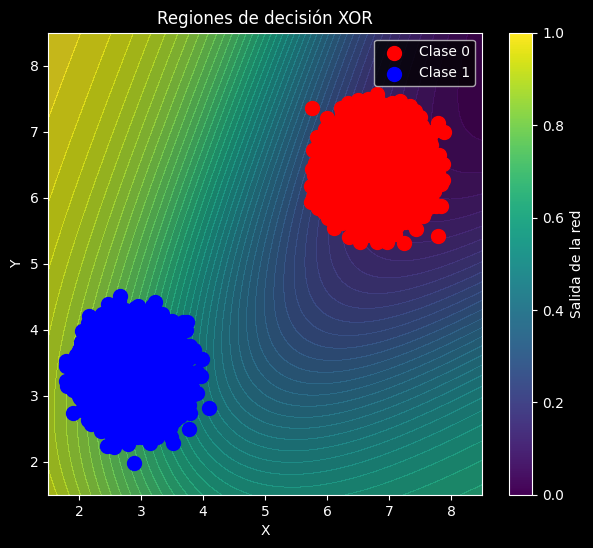

         Configuración     Error Error entrenamiento
0  M : 20, Gamma : 0.9  0.063843            0.063531
1    M : 20, Gamma : 0  0.060979            0.060725
2   M : 2, Gamma : 0.9  0.208512            0.208129
3     M : 2, Gamma : 0  0.137799            0.137721


In [8]:
class Analyze:

    def __init__(self, seed, func):
        train_data, test_data = DatasetGenerator.generate_data(seed,func,0.2)
        print(train_data[0].shape[0])
        visualization.make_scatter(train_data[0][:,0], train_data[0][:, 1], train_data[1])

        self.train_labels = train_data[1].view(-1, 1)
        self.train_data = train_data[0]

        self.test_labels = test_data[1].view(-1, 1)
        self.test_data = test_data[0]

        self.config = [[20, 0.9], [20, 0], [2, 0.9], [2, 0]]

        self.class0 = train_data[0][train_data[1] == 0]
        self.class1 = train_data[0][train_data[1] == 1]

    def run(self):
        table = Table(pd.DataFrame(), ["Configuración", "Error", "Error entrenamiento"], "Comparación_Configuraciones")
        for M, gamma in self.config:
            mlp = MultilayerPerceptron([2, M, 1], 0.01, gamma, 1000)
            history_error, _ = mlp.train_mlp(10000, self.train_data, self.train_labels)
            visualization.make_error_plot(history_error, f"M : {M} Gamma : {gamma}")


            mlp.forward(mlp.transform_data(self.test_data))

            ind = table.obtain_row_count()
            table.add(ind,"Configuración", f"M : {M}, Gamma : {gamma}")
            table.add(ind, "Error", mlp.get_error(self.test_labels))
            table.add(ind, "Error entrenamiento", history_error[-1])

            visualization.make_decision_boundary_plot(mlp.W_o, mlp.W_s, 1.5, 8.5, self.class0, self.class1)
            # visualization.make_decision_boundary_plot(mlp.W_o, mlp.W_s, -1.5, 2.5, self.class0, self.class1)


        table.show()
        table.latex()

separable_analyze = Analyze(444, DatasetGenerator.generate_linearly_separable)
nonseparable_analyze = Analyze(777, DatasetGenerator.generate_nonlinearly_separable)

separable_analyze.run()
# nonseparable_analyze.run()